In [1]:
import numpy as np
from matplotlib import pyplot as plt

"""
Yellow filter
"""
N_Y = np.arange(0, 21)

light_Y = np.array(
    [104.5, 85, 76, 69, 64, 59, 55, 51, 47, 43, 40, 37, 34, 31, 29, 26, 23, 21, 18, 16, 14]
    # 0ой элем. массива - коорд. центра темного петна, остальные - координаты светлых , аналогично и ниже
)
light_Y *= 10

dark_Y = np.array(
    [104.5, 80, 73, 66, 61, 57, 53, 49, 45, 41.5, 38.5, 35, 33, 30, 27, 25, 22, 19, 17, 15, 12.5] 
)
dark_Y *= 10

"""
Green filter
"""
N_G = np.arange(0, 21)

light_G = np.array(
    [106, 80, 73, 67, 63.0, 58, 54, 50.0, 47, 43, 40, 37, 35, 32, 29, 27, 24, 22, 20, 17, 15] 
)
light_G *= 10

dark_G = np.array(
    [106, 84, 77, 70, 64.5, 60.0, 56.0, 52.0, 48.0, 45, 42, 39, 36, 33, 30, 27, 25, 23, 21, 18, 16]
)
dark_G *= 10


"""
Diodes
"""
"""Blue"""
N_B = np.arange(0, 11)

light_B = np.array(
    [100, 77, 70, 65, 60, 56, 52.5, 49, 46, 43, 40]
)
light_B *= 10

dark_B = np.array(
    [100, 73, 67, 62, 58, 54, 51, 47.5, 44, 41.5, 38.5]
)
dark_B *= 10

all_N_B = 16




"""Red"""
N_R = np.arange(0, 11)

light_R = np.array(
    [99, 76, 67, 61, 56, 51, 47, 42.5, 39, 35, 32],
)
light_R *= 10

dark_R = np.array(
    [99, 71, 64, 57, 53, 48.5, 44, 40.5, 37, 34, 30]
)
dark_R *= 10

all_N_R = 37



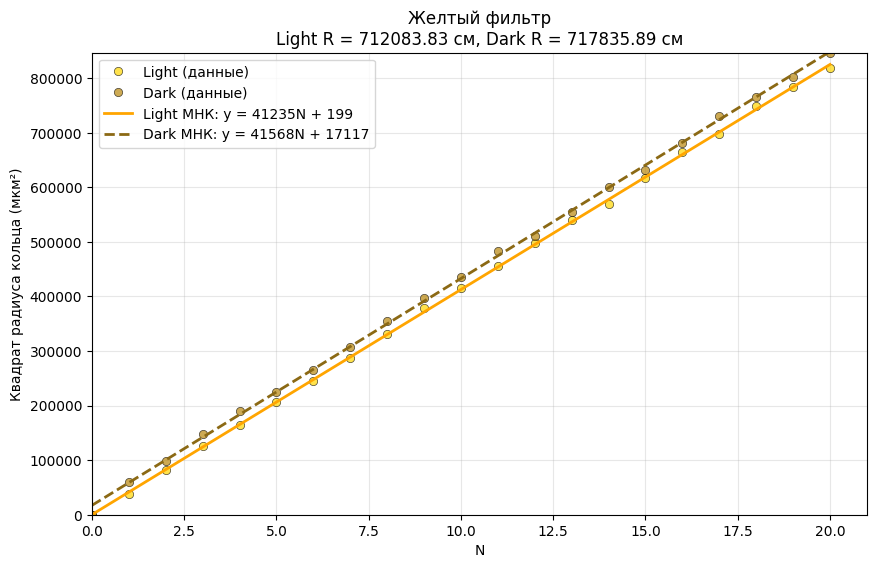

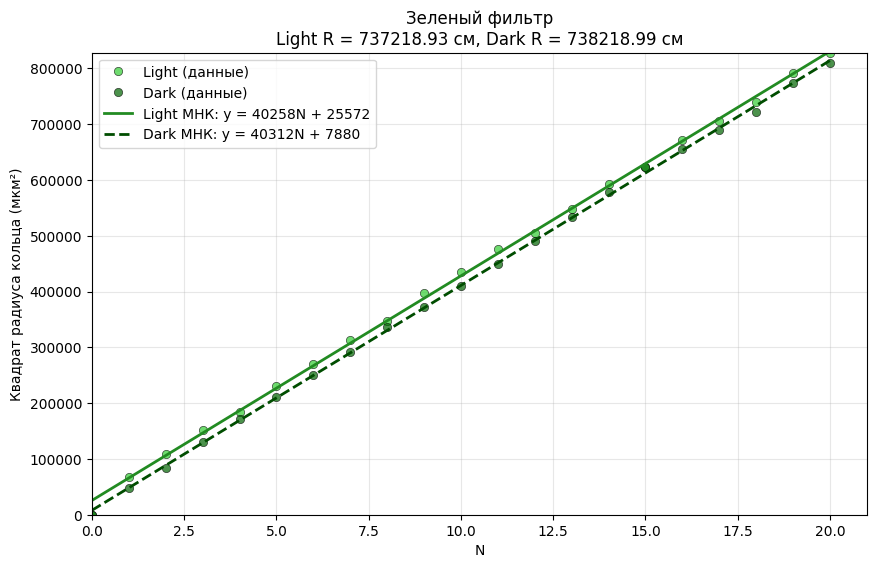

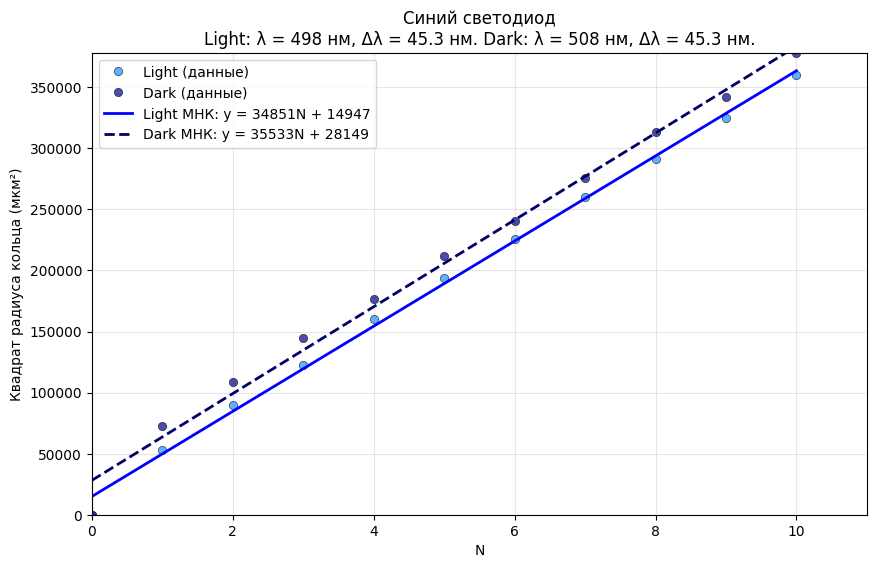

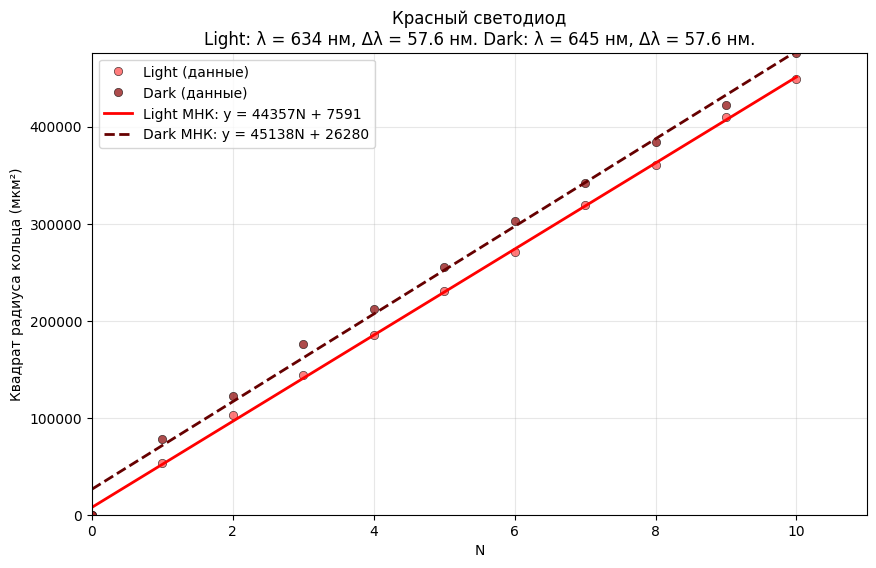

In [2]:
#графики без погрешностей:
def make_graph(N: np.ndarray, light: np.ndarray, dark: np.ndarray, title: str, xlabel: str, ylabel: str, labda: float = None, is_diode: bool = False, color_name: str = None):
    
    # Словарь цветов для light (яркие) и dark (тёмные) версий
    color_map = {
        'yellow': {
            'light_marker': '#FFD700',       # золотисто-жёлтый
            'light_line': '#FFA500',          # оранжево-жёлтый (чтобы линия была видна)
            'dark_marker': '#B8860B',         # тёмно-золотистый
            'dark_line': '#8B6914',           # тёмно-жёлтый/коричневый
        },
        'green': {
            'light_marker': '#32CD32',        # ярко-зелёный (лайм)
            'light_line': '#228B22',          # лесной зелёный
            'dark_marker': '#006400',         # тёмно-зелёный
            'dark_line': '#004D00',           # очень тёмно-зелёный
        },
        'blue': {
            'light_marker': '#1E90FF',        # ярко-голубой (dodger blue)
            'light_line': '#0000FF',          # синий
            'dark_marker': '#00008B',         # тёмно-синий
            'dark_line': '#000066',           # очень тёмно-синий
        },
        'red': {
            'light_marker': '#FF4444',        # ярко-красный
            'light_line': '#FF0000',          # красный
            'dark_marker': '#8B0000',         # тёмно-красный
            'dark_line': '#660000',           # очень тёмно-красный
        },
    }
    
    # Определяем цвет по названию или используем дефолт
    if color_name and color_name.lower() in color_map:
        colors = color_map[color_name.lower()]
    else:
        # Дефолтные цвета (синий/красный как было)
        colors = {
            'light_marker': 'blue',
            'light_line': 'blue',
            'dark_marker': 'red',
            'dark_line': 'red',
        }
    
    plt.figure(figsize=(10, 6))
    
    # Исходные точки
    plt.plot(N, light, 'o', label="Light (данные)", markersize=6, 
             color=colors['light_marker'], alpha=0.7, 
             markeredgecolor='black', markeredgewidth=0.5)
    plt.plot(N, dark, 'o', label="Dark (данные)", markersize=6, 
             color=colors['dark_marker'], alpha=0.7,
             markeredgecolor='black', markeredgewidth=0.5)
    
    # МНК для light
    coefficients_light = np.polyfit(N, light, 1)
    poly_light = np.poly1d(coefficients_light)
    x_fit = np.linspace(min(N), max(N), 100)
    plt.plot(x_fit, poly_light(x_fit), '-', 
             color=colors['light_line'],
             label=f"Light МНК: y = {coefficients_light[0]:.0f}N + {coefficients_light[1]:.0f}", 
             linewidth=2)
    
    # МНК для dark
    coefficients_dark = np.polyfit(N, dark, 1)
    poly_dark = np.poly1d(coefficients_dark)
    plt.plot(x_fit, poly_dark(x_fit), '--', 
             color=colors['dark_line'],
             label=f"Dark МНК: y = {coefficients_dark[0]:.0f}N + {coefficients_dark[1]:.0f}", 
             linewidth=2)
    
    # Расчет R²
    def r(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    light_pred = poly_light(N)
    dark_pred = poly_dark(N)
    
    r_light = r(light, light_pred)
    r_dark = r(dark, dark_pred)
    
    # Заголовок с информацией
    if labda is not None:
        plt.title(f"{title}\nLight R = {(coefficients_light[0]/labda * 10 - 4):.2f} см, Dark R = {(coefficients_dark[0]/labda * 10 - 4):.2f} см", fontsize=12)
    
    if is_diode:
        R = 7 * 10 ** 4
        lambda_light = coefficients_light[0] / R * 1000
        lambda_dark = coefficients_dark[0] / R * 1000
        plt.title(f"{title}\nLight: λ = {lambda_light:.0f} нм, Δλ = {lambda_light / len(N):.1f} нм. Dark: λ = {lambda_dark:.0f} нм, Δλ = {lambda_light / len(N):.1f} нм.", fontsize=12)
    
    plt.xlabel(xlabel)
    plt.xlim(0, max(N) + 1)
    plt.ylim(0, max(max(light), max(dark)) + 10)
    plt.ylabel(ylabel)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.savefig(f"./{title.replace(' ', '_').lower()}.png", dpi=150, bbox_inches='tight')
    # plt.show()
    
    return {
        'light': {'coefficients': coefficients_light, 'r': r_light},
        'dark': {'coefficients': coefficients_dark, 'r': r_dark}
    }


if __name__ == "__main__":

    """Фильтры"""
    """Yellow filter"""
    make_graph(N_Y, np.abs(light_Y - light_Y[0])**2, np.abs(dark_Y - dark_Y[0])**2, 
               "Желтый фильтр", "N", "Квадрат радиуса кольца (мкм²)", 
               labda=0.57907, color_name='yellow')
    
    """Green filter"""
    make_graph(N_G, np.abs(light_G - light_G[0])**2, np.abs(dark_G - dark_G[0])**2, 
               "Зеленый фильтр", "N", "Квадрат радиуса кольца (мкм²)", 
               labda=0.54607, color_name='green')

    """Diodes"""
    make_graph(N_B, np.abs(light_B - light_B[0])**2, np.abs(dark_B - dark_B[0])**2, 
               "Синий светодиод", "N", "Квадрат радиуса кольца (мкм²)", 
               is_diode=True, color_name='blue')
    
    make_graph(N_R, np.abs(light_R - light_R[0])**2, np.abs(dark_R - dark_R[0])**2, 
               "Красный светодиод", "N", "Квадрат радиуса кольца (мкм²)", 
               is_diode=True, color_name='red')

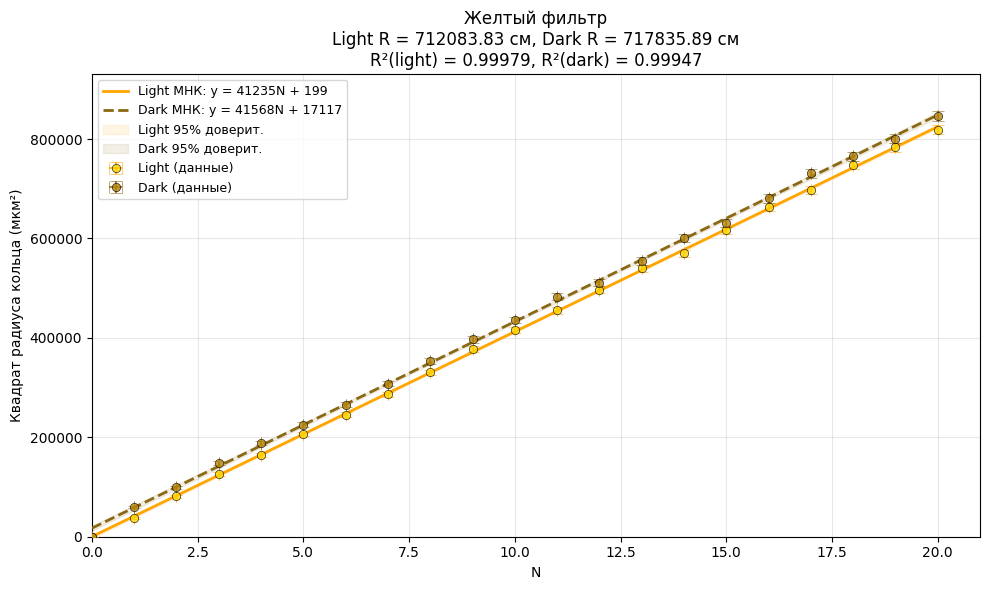

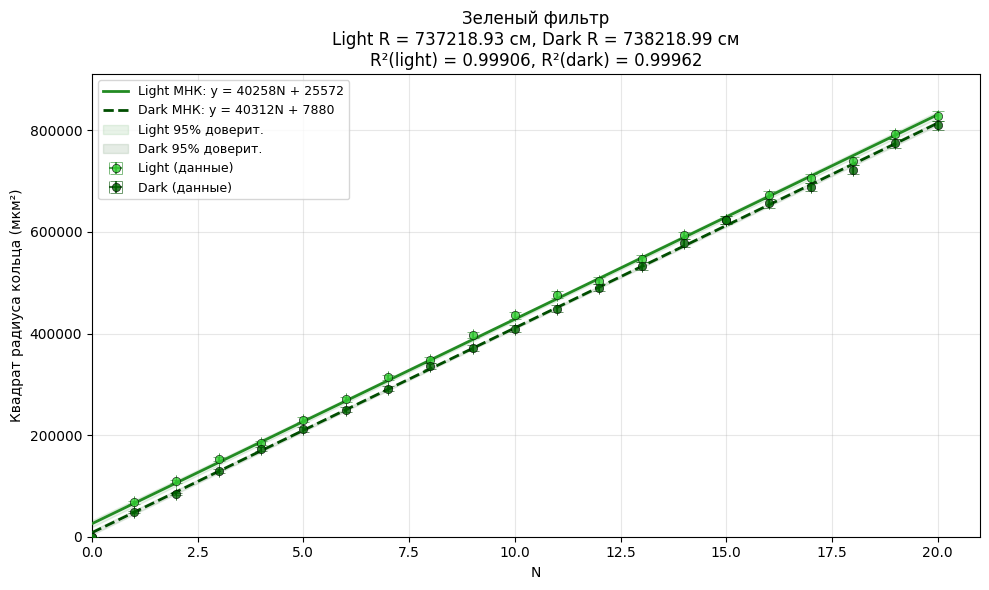

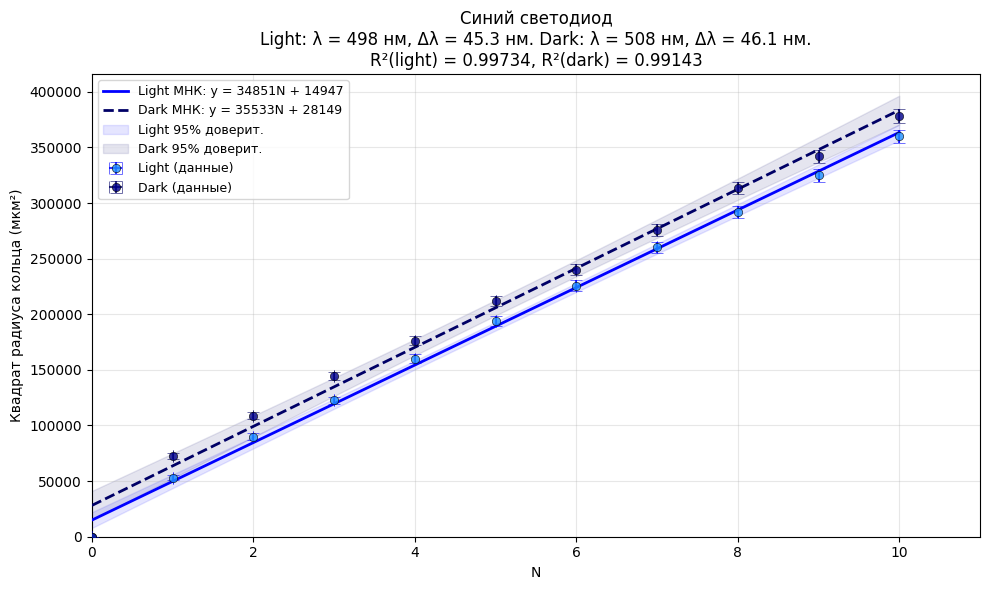

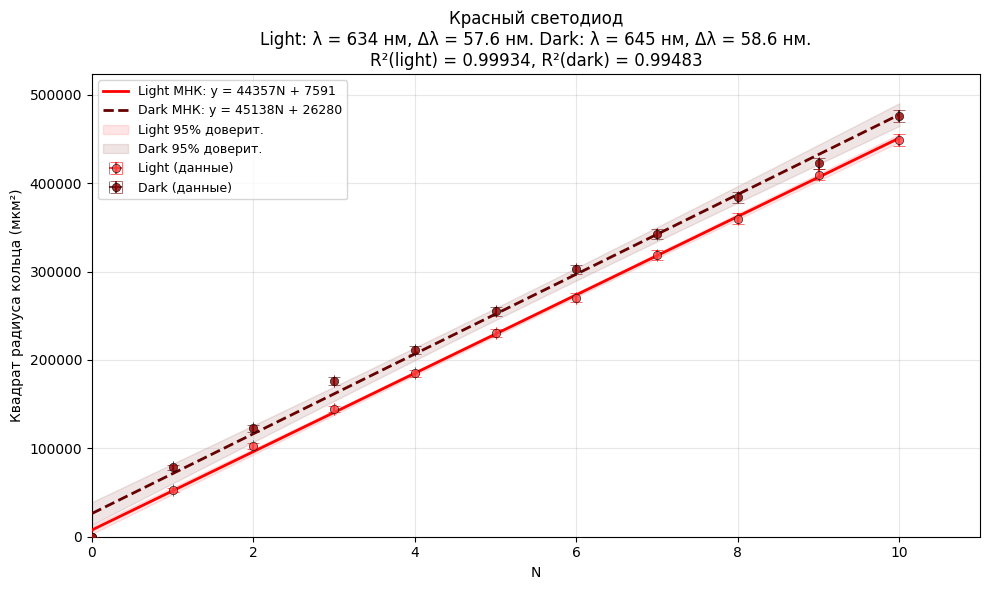

In [3]:
#графики с погрешностями
def make_graph(N: np.ndarray, light: np.ndarray, dark: np.ndarray, 
               title: str, xlabel: str, ylabel: str, 
               labda: float = None, is_diode: bool = False, color_name: str = None,
               N_err: np.ndarray = None, light_err: np.ndarray = None, 
               dark_err: np.ndarray = None):
    
    # Словарь цветов для light (яркие) и dark (тёмные) версий
    color_map = {
        'yellow': {
            'light_marker': '#FFD700',
            'light_line': '#FFA500',
            'dark_marker': '#B8860B',
            'dark_line': '#8B6914',
        },
        'green': {
            'light_marker': '#32CD32',
            'light_line': '#228B22',
            'dark_marker': '#006400',
            'dark_line': '#004D00',
        },
        'blue': {
            'light_marker': '#1E90FF',
            'light_line': '#0000FF',
            'dark_marker': '#00008B',
            'dark_line': '#000066',
        },
        'red': {
            'light_marker': '#FF4444',
            'light_line': '#FF0000',
            'dark_marker': '#8B0000',
            'dark_line': '#660000',
        },
    }
    
    if color_name and color_name.lower() in color_map:
        colors = color_map[color_name.lower()]
    else:
        colors = {
            'light_marker': 'blue',
            'light_line': 'blue',
            'dark_marker': 'red',
            'dark_line': 'red',
        }
    
    plt.figure(figsize=(10, 6))
    
    # =============================================
    # Погрешности по умолчанию (если не переданы)
    # =============================================
    if N_err is None:
        N_err = np.zeros_like(N, dtype=float)
    
    if light_err is None:
        # Оценка погрешности: стандартное отклонение остатков МНК
        coeffs_tmp = np.polyfit(N, light, 1)
        residuals = light - np.polyval(coeffs_tmp, N)
        light_err = np.full_like(light, np.std(residuals), dtype=float)
    
    if dark_err is None:
        coeffs_tmp = np.polyfit(N, dark, 1)
        residuals = dark - np.polyval(coeffs_tmp, N)
        dark_err = np.full_like(dark, np.std(residuals), dtype=float)
    
    # =============================================
    # Мальтийские кресты (errorbar) для Light
    # =============================================
    plt.errorbar(N, light, 
                 xerr=N_err, yerr=light_err,
                 fmt='o',                          # маркер — кружок
                 markersize=6,
                 color=colors['light_marker'],
                 ecolor=colors['light_line'],      # цвет усов
                 elinewidth=1.5,                   # толщина усов
                 capsize=4,                        # длина "шляпок" (перекладины креста)
                 capthick=1.5,                     # толщина "шляпок"
                 markeredgecolor='black',
                 markeredgewidth=0.5,
                 alpha=0.8,
                 label="Light (данные)",
                 zorder=5)
    
    # =============================================
    # Мальтийские кресты (errorbar) для Dark
    # =============================================
    plt.errorbar(N, dark, 
                 xerr=N_err, yerr=dark_err,
                 fmt='o',
                 markersize=6,
                 color=colors['dark_marker'],
                 ecolor=colors['dark_line'],
                 elinewidth=1.5,
                 capsize=4,
                 capthick=1.5,
                 markeredgecolor='black',
                 markeredgewidth=0.5,
                 alpha=0.8,
                 label="Dark (данные)",
                 zorder=5)
    
    # =============================================
    # МНК для light
    # =============================================
    coefficients_light = np.polyfit(N, light, 1)
    poly_light = np.poly1d(coefficients_light)
    x_fit = np.linspace(min(N), max(N), 100)
    plt.plot(x_fit, poly_light(x_fit), '-', 
             color=colors['light_line'],
             label=f"Light МНК: y = {coefficients_light[0]:.0f}N + {coefficients_light[1]:.0f}",linewidth=2, zorder=3)
    
    # =============================================
    # МНК для dark
    # =============================================
    coefficients_dark = np.polyfit(N, dark, 1)
    poly_dark = np.poly1d(coefficients_dark)
    plt.plot(x_fit, poly_dark(x_fit), '--', 
             color=colors['dark_line'],
             label=f"Dark МНК: y = {coefficients_dark[0]:.0f}N + {coefficients_dark[1]:.0f}", 
             linewidth=2, zorder=3)
    
    # =============================================
    # Доверительная полоса (опционально — красивое дополнение)
    # =============================================
    # Стандартная ошибка предсказания для light
    n = len(N)
    N_mean = np.mean(N)
    S_light = np.sqrt(np.sum((light - poly_light(N))**2) / (n - 2))
    se_light = S_light * np.sqrt(1/n + (x_fit - N_mean)**2 / np.sum((N - N_mean)**2))
    
    plt.fill_between(x_fit, 
                     poly_light(x_fit) - 2*se_light, 
                     poly_light(x_fit) + 2*se_light,
                     color=colors['light_line'], alpha=0.1, 
                     label="Light 95% доверит.", zorder=1)
    
    # Стандартная ошибка предсказания для dark
    S_dark = np.sqrt(np.sum((dark - poly_dark(N))**2) / (n - 2))
    se_dark = S_dark * np.sqrt(1/n + (x_fit - N_mean)**2 / np.sum((N - N_mean)**2))
    
    plt.fill_between(x_fit, 
                     poly_dark(x_fit) - 2*se_dark, 
                     poly_dark(x_fit) + 2*se_dark,
                     color=colors['dark_line'], alpha=0.1, 
                     label="Dark 95% доверит.", zorder=1)
    
    # =============================================
    # R²
    # =============================================
    def calc_r2(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    r_light = calc_r2(light, poly_light(N))
    r_dark = calc_r2(dark, poly_dark(N))
    
    # =============================================
    # Заголовок
    # =============================================
    if labda is not None:
        plt.title(f"{title}\nLight R = {(coefficients_light[0]/labda * 10 - 4):.2f} см, "
                  f"Dark R = {(coefficients_dark[0]/labda * 10 - 4):.2f} см\n"
                  f"R²(light) = {r_light:.5f}, R²(dark) = {r_dark:.5f}", fontsize=12)
    
    if is_diode:
        R = 7 * 10 ** 4
        lambda_light = coefficients_light[0] / R * 1000
        lambda_dark = coefficients_dark[0] / R * 1000
        plt.title(f"{title}\n"
                  f"Light: λ = {lambda_light:.0f} нм, Δλ = {lambda_light / len(N):.1f} нм. "
                  f"Dark: λ = {lambda_dark:.0f} нм, Δλ = {lambda_dark / len(N):.1f} нм.\n"
                  f"R²(light) = {r_light:.5f}, R²(dark) = {r_dark:.5f}", fontsize=12)
    
    plt.xlabel(xlabel)
    plt.xlim(0, max(N) + 1)
    plt.ylim(0, max(max(light), max(dark)) * 1.1)
    plt.ylabel(ylabel)
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(f"./{title.replace(' ', '_').lower()}.png", dpi=150, bbox_inches='tight')
    # plt.show()
    
    return {
        'light': {'coefficients': coefficients_light, 'r2': r_light},
        'dark': {'coefficients': coefficients_dark, 'r2': r_dark}
            }


if __name__ == "__main__":
    
    # =============================================
    # Пример задания погрешностей (подставьте свои)
    # =============================================
    # Погрешность по N (например, ±0.5 для всех точек)
    # Погрешность по радиусу — инструментальная (например, δr = 5 мкм)
    # Тогда δ(r²) = 2r·δr — зависит от самого r
    
    delta_r = 5  # мкм — инструментальная погрешность измерения радиуса
    
    # Для жёлтого фильтра (пример расчёта погрешности δ(r²))
    light_Y_shifted = np.abs(light_Y - light_Y[0])
    dark_Y_shifted = np.abs(dark_Y - dark_Y[0])
    light_Y_sq = light_Y_shifted**2
    dark_Y_sq = dark_Y_shifted**2
    light_Y_err = 2 * light_Y_shifted * delta_r  # δ(r²) = 2r·δr
    dark_Y_err = 2 * dark_Y_shifted * delta_r
    N_Y_err = np.full_like(N_Y, 0.0, dtype=float)  # если N точно известно
    
    """Yellow filter"""
    make_graph(N_Y, light_Y_sq, dark_Y_sq,
               "Желтый фильтр", "N", "Квадрат радиуса кольца (мкм²)",
               labda=0.57907, color_name='yellow',
               N_err=N_Y_err, light_err=light_Y_err, dark_err=dark_Y_err)
    
    # Для зелёного фильтра
    light_G_shifted = np.abs(light_G - light_G[0])
    dark_G_shifted = np.abs(dark_G - dark_G[0])
    light_G_sq = light_G_shifted**2
    dark_G_sq = dark_G_shifted**2
    light_G_err = 2 * light_G_shifted * delta_r
    dark_G_err = 2 * dark_G_shifted * delta_r
    N_G_err = np.full_like(N_G, 0.0, dtype=float)
    
    """Green filter"""
    make_graph(N_G, light_G_sq, dark_G_sq,
               "Зеленый фильтр", "N", "Квадрат радиуса кольца (мкм²)",
               labda=0.54607, color_name='green',
               N_err=N_G_err, light_err=light_G_err, dark_err=dark_G_err)
    
    # Для синего светодиода
    light_B_shifted = np.abs(light_B - light_B[0])
    dark_B_shifted = np.abs(dark_B - dark_B[0])
    light_B_sq = light_B_shifted**2
    dark_B_sq = dark_B_shifted**2
    light_B_err = 2 * light_B_shifted * delta_r
    dark_B_err = 2 * dark_B_shifted * delta_r
    N_B_err = np.full_like(N_B, 0.0, dtype=float)
    
    """Blue diode"""
    make_graph(N_B, light_B_sq, dark_B_sq,
               "Синий светодиод", "N", "Квадрат радиуса кольца (мкм²)",
               is_diode=True, color_name='blue',
               N_err=N_B_err, light_err=light_B_err, dark_err=dark_B_err)
    
    # Для красного светодиода
    light_R_shifted = np.abs(light_R - light_R[0])
    dark_R_shifted = np.abs(dark_R - dark_R[0])
    light_R_sq = light_R_shifted**2
    dark_R_sq = dark_R_shifted**2
    light_R_err = 2 * light_R_shifted * delta_r
    dark_R_err = 2 * dark_R_shifted * delta_r
    N_R_err = np.full_like(N_R, 0.0, dtype=float)
    
    """Red diode"""
    make_graph(N_R, light_R_sq, dark_R_sq,
               "Красный светодиод", "N", "Квадрат радиуса кольца (мкм²)",
               is_diode=True, color_name='red',
               N_err=N_R_err, light_err=light_R_err, dark_err=dark_R_err)

In [4]:
# =============================================
# КОНСТАНТЫ
# =============================================
LAMBDA_YELLOW = 0.57907  # мкм
LAMBDA_GREEN = 0.54607   # мкм
R_NOMINAL = 7e4          # мкм (7 см = 70 мм = 70000 мкм) — номинальный радиус
DELTA_R_INSTRUMENT = 5   # мкм — инструментальная погрешность измерения радиуса кольца


def make_graph(N, light, dark, title, xlabel, ylabel,
               labda=None, is_diode=False, color_name=None,
               N_err=None, light_err=None, dark_err=None):
    """
    Построение графика r² от N с мальтийскими крестами погрешностей,
    линейной аппроксимацией МНК и доверительными полосами.
    
    Возвращает словарь с коэффициентами, R², радиусом кривизны и погрешностями.
    """

    color_map = {
        'yellow': {
            'light_marker': '#FFD700', 'light_line': '#FFA500',
            'dark_marker': '#B8860B',  'dark_line': '#8B6914',
        },
        'green': {
            'light_marker': '#32CD32', 'light_line': '#228B22',
            'dark_marker': '#006400',  'dark_line': '#004D00',
        },
        'blue': {
            'light_marker': '#1E90FF', 'light_line': '#0000FF',
            'dark_marker': '#00008B',  'dark_line': '#000066',
        },
        'red': {
            'light_marker': '#FF4444', 'light_line': '#FF0000',
            'dark_marker': '#8B0000',  'dark_line': '#660000',
        },
    }

    colors = color_map.get(color_name.lower(), {
        'light_marker': 'blue', 'light_line': 'blue',
        'dark_marker': 'red',  'dark_line': 'red',
    }) if color_name else {
        'light_marker': 'blue', 'light_line': 'blue',
        'dark_marker': 'red',  'dark_line': 'red',
    }

    # --- Погрешности по умолчанию ---
    if N_err is None:
        N_err = np.zeros_like(N, dtype=float)
    if light_err is None:
        c_tmp = np.polyfit(N, light, 1)
        light_err = np.full_like(light, np.std(light - np.polyval(c_tmp, N)), dtype=float)
    if dark_err is None:
        c_tmp = np.polyfit(N, dark, 1)
        dark_err = np.full_like(dark, np.std(dark - np.polyval(c_tmp, N)), dtype=float)

    plt.figure(figsize=(10, 6))

    # --- Мальтийские кресты ---
    plt.errorbar(N, light, xerr=N_err, yerr=light_err,
                 fmt='o', markersize=6, color=colors['light_marker'],
                 ecolor=colors['light_line'], elinewidth=1.5,
                 capsize=4, capthick=1.5, markeredgecolor='black',
                 markeredgewidth=0.5, alpha=0.8, label="Light", zorder=5)

    plt.errorbar(N, dark, xerr=N_err, yerr=dark_err,
                 fmt='o', markersize=6, color=colors['dark_marker'],
                 ecolor=colors['dark_line'], elinewidth=1.5,
                 capsize=4, capthick=1.5, markeredgecolor='black',
                 markeredgewidth=0.5, alpha=0.8, label="Dark", zorder=5)
    # --- МНК ---
    coefficients_light = np.polyfit(N, light, 1)
    coefficients_dark = np.polyfit(N, dark, 1)
    poly_light = np.poly1d(coefficients_light)
    poly_dark = np.poly1d(coefficients_dark)

    x_fit = np.linspace(min(N), max(N), 200)
    plt.plot(x_fit, poly_light(x_fit), '-', color=colors['light_line'],
             label=f"Light МНК: y = {coefficients_light[0]:.0f}N + {coefficients_light[1]:.0f}",
             linewidth=2, zorder=3)
    plt.plot(x_fit, poly_dark(x_fit), '--', color=colors['dark_line'],
             label=f"Dark МНК: y = {coefficients_dark[0]:.0f}N + {coefficients_dark[1]:.0f}",
             linewidth=2, zorder=3)

    # --- Доверительные полосы ---
    n = len(N)
    N_mean = np.mean(N)
    S_xx = np.sum((N - N_mean)**2)

    for poly, data, col in [(poly_light, light, colors['light_line']),
                             (poly_dark, dark, colors['dark_line'])]:
        S = np.sqrt(np.sum((data - poly(N))**2) / (n - 2))
        se = S * np.sqrt(1 / n + (x_fit - N_mean)**2 / S_xx)
        plt.fill_between(x_fit, poly(x_fit) - 2 * se, poly(x_fit) + 2 * se,
                         color=col, alpha=0.08, zorder=1)

    # --- R² ---
    def calc_r2(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - ss_res / ss_tot if ss_tot != 0 else 0

    r2_light = calc_r2(light, poly_light(N))
    r2_dark = calc_r2(dark, poly_dark(N))

    # =============================================
    # РАСЧЁТ РАДИУСА КРИВИЗНЫ И ПОГРЕШНОСТЕЙ
    # =============================================
    # r² = N·λ·R  =>  наклон k = λ·R  =>  R = k / λ
    #
    # Погрешность наклона (стандартная ошибка):
    #   σ_k = S / sqrt(S_xx),  где S = sqrt(Σ(yi - ŷi)² / (n-2))
    #
    # Погрешность R:
    #   σ_R = σ_k / λ   (при δλ << λ)

    results = {}

    for label, coeffs, data, r2_val in [
        ('light', coefficients_light, light, r2_light),
        ('dark', coefficients_dark, dark, r2_dark)
    ]:
        k = coeffs[0]  # наклон (мкм²/кольцо)
        S = np.sqrt(np.sum((data - np.polyval(coeffs, N))**2) / (n - 2))
        sigma_k = S / np.sqrt(S_xx)  # стандартная ошибка наклона

        results[label] = {
            'coefficients': coeffs,
            'r2': r2_val,
            'k': k,
            'sigma_k': sigma_k,
        }

    # --- Заголовок ---
    title_lines = [title]

    if labda is not None:
        for label in ['light', 'dark']:
            k = results[label]['k']
            sigma_k = results[label]['sigma_k']
            R_calc = k / labda          # мкм
            sigma_R = sigma_k / labda   # мкм
            R_cm = R_calc * 1e-4        # см
            sigma_R_cm = sigma_R * 1e-4 # см
            results[label]['R_um'] = R_calc
            results[label]['sigma_R_um'] = sigma_R
            results[label]['R_cm'] = R_cm
            results[label]['sigma_R_cm'] = sigma_R_cm

        title_lines.append(
            f"Light: R = ({results['light']['R_cm']:.2f} ± {results['light']['sigma_R_cm']:.2f}) см, "
            f"R² = {results['light']['r2']:.5f}"
        )
        title_lines.append(
            f"Dark: R = ({results['dark']['R_cm']:.2f} ± {results['dark']['sigma_R_cm']:.2f}) см, "
            f"R² = {results['dark']['r2']:.5f}"
        )

    if is_diode:
        for label in ['light', 'dark']:
            k = results[label]['k']
            sigma_k = results[label]['sigma_k']
            lam = k / R_NOMINAL * 1e3       # нм  (r² = NλR => λ = k/R)
            sigma_lam = sigma_k / R_NOMINAL * 1e3  # нм
            results[label]['lambda_nm'] = lam
            results[label]['sigma_lambda_nm'] = sigma_lam

        title_lines.append(
            f"Light: λ = ({results['light']['lambda_nm']:.0f} ± {results['light']['sigma_lambda_nm']:.1f}) нм, "
            f"R² = {results['light']['r2']:.5f}"
        )
        title_lines.append(
            f"Dark: λ = ({results['dark']['lambda_nm']:.0f} ± {results['dark']['sigma_lambda_nm']:.1f}) нм, "
            f"R² = {results['dark']['r2']:.5f}"
        )
        plt.title("\n".join(title_lines), fontsize=11)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(0, max(N) + 1)
    plt.ylim(0, max(max(light), max(dark)) * 1.15)
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"./{title.replace(' ', '_').lower()}.png", dpi=150, bbox_inches='tight')
    plt.close()

    return results


def analysis_report(all_results):
    """
    =============================================
    ПОДРОБНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ
    =============================================
    
    1. Какой вышел радиус кривизны линзы?
    2. Какая погрешность измерения?
    3. Минимальная σ при N → ∞?
    4. Как уменьшить погрешность?
    """

    print("=" * 70)
    print("         АНАЛИЗ РЕЗУЛЬТАТОВ: КОЛЬЦА НЬЮТОНА")
    print("=" * 70)

    # =============================================
    # 1. РАДИУС КРИВИЗНЫ ЛИНЗЫ
    # =============================================
    print("\n" + "─" * 70)
    print("1. РАДИУС КРИВИЗНЫ ЛИНЗЫ R")
    print("─" * 70)
    print("""
    Формула: r²_N = N · λ · R
    
    График r² vs N — прямая с наклоном k = λ · R
    Отсюда:  R = k / λ
    
    Погрешность наклона (МНК):
        σ_k = S_остатков / √(Σ(Ni - N̄)²)
        
    Погрешность радиуса:
        σ_R = σ_k / λ
    """)

    R_values = []
    for name, res in all_results.items():
        if 'R_cm' in res.get('light', {}):
            for lbl in ['light', 'dark']:
                R_val = res[lbl]['R_cm']
                sig = res[lbl]['sigma_R_cm']
                R_values.append(R_val)
                print(f"    {name:20s} ({lbl:5s}): R = ({R_val:.3f} ± {sig:.3f}) см")
                print(f"    {'':20s}         σ_отн = {sig/R_val*100:.2f}%")

    if R_values:
        R_mean = np.mean(R_values)
        R_std = np.std(R_values, ddof=1) / np.sqrt(len(R_values))
        print(f"\n    >>> СРЕДНЕЕ по фильтрам: R = ({R_mean:.3f} ± {R_std:.3f}) см")
        print(f"    >>> Номинальное значение: R = {R_NOMINAL*1e-4:.1f} см")
        print(f"    >>> Отклонение от номинала: {abs(R_mean - R_NOMINAL*1e-4)/R_NOMINAL*1e-4*100:.1f}%")

    # =============================================
    # 2. ДЛИНА ВОЛНЫ СВЕТОДИОДОВ
    # =============================================
    print("\n" + "─" * 70)
    print("2. ДЛИНА ВОЛНЫ СВЕТОДИОДОВ")
    print("─" * 70)
    print("""
    Формула: λ = k / R,  где R — известный радиус кривизны
    
    Погрешность:
        σ_λ = σ_k / R   (при σ_R << R)
    """)

    for name, res in all_results.items():
        if 'lambda_nm' in res.get('light', {}):
            for lbl in ['light', 'dark']:
                lam = res[lbl]['lambda_nm']
                sig = res[lbl]['sigma_lambda_nm']
                print(f"    {name:20s} ({lbl:5s}): λ = ({lam:.1f} ± {sig:.1f}) нм")

    # =============================================
    # 3. МИНИМАЛЬНАЯ σ ПРИ N → ∞
    # =============================================
    print("\n" + "─" * 70)
    print("3. МИНИМАЛЬНАЯ σ ПРИ БЕСКОНЕЧНОМ ЧИСЛЕ ИЗМЕРЕНИЙ (N → ∞)")
    print("─" * 70)
    print("""
    ┌─────────────────────────────────────────────────────────────────┐
    │  При увеличении числа колец N → ∞:                              │
    │                                                                 │
    │  Статистическая погрешность наклона:                            │
    │      σ_k = S / √(S_xx)  →  0   при  S_xx → ∞                    │
    │                                                                 │
    │  НО! Остаётся СИСТЕМАТИЧЕСКАЯ погрешность:                      │
    │                                                                 │
    │  σ_R_min = (σ_instrument)² · 2r_max / (λ · √S_xx)               │
    │                                                                 │
    │  Источники неустранимых погрешностей:                           │
    │  • Инструментальная погрешность δr (микроскоп/окуляр)           │
    │  • Неидеальность сферической поверхности линзы                  │
    │  • Деформация линзы под собственным весом                       │
    │  • Пылинки и загрязнения в зазоре                               │
    │  • Неточность определения центра колец                          │
    │  • Конечная ширина интерференционных полос                      │
    │  • Неточность длины волны источника (Δλ)                        │
    └─────────────────────────────────────────────────────────────────┘
    """)

    # Оценка минимальной погрешности
    delta_r = DELTA_R_INSTRUMENT  # мкм
    # δ(r²) ≈ 2r·δr, при r ~ 300 мкм (типичный радиус 10-го кольца)
    r_typical = 300  # мкм — типичный радиус большого кольца
    delta_r_sq = 2 * r_typical * delta_r  # погрешность r²

    # Для N колец: S_xx = N(N²-1)/12 (для равномерной сетки 1..N)
    for N_test in [10, 20, 50, 100, 1000]:
        S_xx_test = N_test * (N_test**2 - 1) / 12
        sigma_k_min = delta_r_sq / np.sqrt(S_xx_test)
        sigma_R_min = sigma_k_min / LAMBDA_YELLOW  # для жёлтого фильтра
        print(f"    N = {N_test:4d} колец: σ_k ≈ {sigma_k_min:.1f} мкм², "
              f"σ_R ≈ {sigma_R_min:.0f} мкм = {sigma_R_min*1e-4:.4f} см "
              f"({sigma_R_min/R_NOMINAL*100:.3f}%)")

    print(f"""
    >>> При δr = {delta_r} мкм (инструментальная), σ_R → 0 при N → ∞
    >>> Но на практике:
    >>>   • Большие кольца (N > 20-30) становятся размытыми
    >>>   • Аберрации линзы дают систематику ~ 0.1-1%
    >>>   • Реалистичный предел: σ_R ~ {delta_r*2*r_typical/np.sqrt(10*(100-1)/12)/LAMBDA_YELLOW*1e-4:.3f} см
    """)

    # =============================================
    # 4. КАК УМЕНЬШИТЬ ПОГРЕШНОСТЬ
    # =============================================
    print("─" * 70)
    print("4. СПОСОБЫ УМЕНЬШЕНИЯ ПОГРЕШНОСТИ")
    print("─" * 70)
    print("""
    ┌─────────────────────────────────────────────────────────────────┐
    │  СПОСОБ 1: ПОДЛОЖИТЬ МОНЕТКУ (или прокладку)                    │
    │  ───────────────────────────────────────────────────────────────│
    │                                                                 │
    │  Зачем: Создать воздушный клин → кольца Ньютона                 │
    │         сместятся и изменят масштаб.                            │
    │                                                                 │
    │  На практике: если подложить тонкую прокладку толщиной h        │
    │  на расстоянии L от центра, то:                                 │
    │    • Центр интерференционной картины смещается                  │
    │    • Кольца вытягиваются в эллипсы                              │
    │    • Можно измерять интервалы между кольцами точнее,            │
    │      т.к. они становятся шире в одном направлении               │
    │                                                                 │
    │  Метод позволяет УВЕЛИЧИТЬ ВИДИМЫЙ РАЗМЕР колец,                │
    │  уменьшая относительную погрешность δr/r                        │
    │                                                                 │
    │  Также исключается ошибка определения нулевого кольца!          │
    │  (используем разность: r²_m - r²_n = (m-n)·λ·R)                 │
    └─────────────────────────────────────────────────────────────────┘
    
    ┌─────────────────────────────────────────────────────────────────┐
    │  СПОСОБ 2: ИНТЕРФЕРОМЕТР ФАБРИ-ПЕРО                             │
    │  ───────────────────────────────────────────────────────────────│
    │                                                                 │
    │  Если стремить Δ → 0 (толщину зазора → 0), то нужно             │
    │  использовать интерферометр Фабри-Перо:                         │
    │                                                                 │
    │  ПРЕИМУЩЕСТВА:                                                  │
    │  1) Многолучевая интерференция (не двухлучевая)                 │
    │  2) Кольца ОЧЕНЬ УЗКИЕ и ЯРКИЕ                                  │
    │    (резкость F = π√R_отр / (1-R_отр) >> 1)                      │
    │  3) Ширина полосы δ ~ λ/(N_эфф · m), где N_эфф ~ 30-100         │
    │  4)  Можно определять положение максимума с точностью           │
    │    до 1/50 - 1/100 ширины полосы                                │
    │  5) Разрешающая способность R ~ m·F ~ 10⁵ - 10⁶                 │
    │                                                                 │
    │  СРАВНЕНИЕ:                                                     │
    │  ┌───────────────────┬──────────────┬─────────────────┐         │
    │  │ Параметр          │ Ньютон       │ Фабри-Перо      │         │
    │  ├───────────────────┼──────────────┼─────────────────┤         │
    │  │ Тип интерференции │ 2-лучевая    │ Многолучевая    │         │
    │  │ Контраст полос    │ Низкий       │ Очень высокий   │         │
    │  │ Ширина полос      │ ~ λ/2        │ ~ λ/(2F)        │         │
    │  │ Точность          │ ~ 1-5%       │ ~ 0.01-0.1%     │         │
    │  │ Разрешение        │ ~ 10²-10³    │ ~ 10⁵-10⁶       │         │
    │  └───────────────────┴──────────────┴─────────────────┘         │
    │                                                                 │
    │  ФИЗИКА:                                                        │
    │  В интерферометре Фабри-Перо свет многократно отражается        │
    │  между двумя высокоотражающими зеркалами. Суммарная             │
    │  амплитуда:                                                     │
    │    I = I_0 / (1 + F·sin²(δ/2))                                  │
    │  где F = 4R/(1-R)² — коэффициент резкости (finesse²)            │
    │                                                                 │
    │  При R_отражения → 1: полосы → δ-функции (бесконечно узкие)     │
    └─────────────────────────────────────────────────────────────────┘
    
    ┌─────────────────────────────────────────────────────────────────┐
    │  СПОСОБ 3: ДРУГИЕ МЕТОДЫ УМЕНЬШЕНИЯ ПОГРЕШНОСТИ                 │
    │  ───────────────────────────────────────────────────────────────│
    │                                                                 │
    │  • Использовать метод разностей r²_(m+p) - r²_m = p·λ·R         │
    │    (исключает ошибку нулевого кольца!)                          │
    │                                                                 │
    │  • CCD-камера вместо окулярного микрометра                      │
    │    (δr ~ 1 пиксель ~ 1-3 мкм вместо 5-10 мкм)                   │
    │                                                                 │
    │  • Цифровая обработка: фит окружности по изображению            │
    │    (суб-пиксельная точность ~ 0.1 мкм)                          │
    │                                                                 │
    │  • Монохроматический источник с узкой линией (лазер)            │
    │    (убирает размытие от Δλ)                                     │
    │                                                                 │
    │  • Термостабилизация (убирает дрейф зазора от нагрева)          │
    │                                                                 │
    │  • Увеличить число наблюдаемых колец (больше N в МНК)           │
    │    σ_k ~ 1/√N, но ограничено размытием дальних колец            │
    └─────────────────────────────────────────────────────────────────┘
    """)


if __name__ == "__main__":

    delta_r = DELTA_R_INSTRUMENT  # 5 мкм

    all_results = {}

    # =============================================
    # ФИЛЬТРЫ
    # =============================================

    # --- Жёлтый ---
    light_Y_shifted = np.abs(light_Y - light_Y[0])
    dark_Y_shifted = np.abs(dark_Y - dark_Y[0])
    light_Y_sq = light_Y_shifted**2
    dark_Y_sq = dark_Y_shifted**2
    light_Y_err = 2 * light_Y_shifted * delta_r
    dark_Y_err = 2 * dark_Y_shifted * delta_r
    N_Y_err = np.full_like(N_Y, 0.0, dtype=float)

    res_Y = make_graph(N_Y, light_Y_sq, dark_Y_sq,
                       "Желтый фильтр", "N", "Квадрат радиуса кольца (мкм²)",
                       labda=LAMBDA_YELLOW, color_name='yellow',
                       N_err=N_Y_err, light_err=light_Y_err, dark_err=dark_Y_err)
    all_results["Жёлтый фильтр"] = res_Y

    # --- Зелёный ---
    light_G_shifted = np.abs(light_G - light_G[0])
    dark_G_shifted = np.abs(dark_G - dark_G[0])
    light_G_sq = light_G_shifted**2
    dark_G_sq = dark_G_shifted**2
    light_G_err = 2 * light_G_shifted * delta_r
    dark_G_err = 2 * dark_G_shifted * delta_r
    N_G_err = np.full_like(N_G, 0.0, dtype=float)

    res_G = make_graph(N_G, light_G_sq, dark_G_sq,
                       "Зеленый фильтр", "N", "Квадрат радиуса кольца (мкм²)",
                       labda=LAMBDA_GREEN, color_name='green',
                       N_err=N_G_err, light_err=light_G_err, dark_err=dark_G_err)
    all_results["Зелёный фильтр"] = res_G

    # =============================================
    # СВЕТОДИОДЫ
    # =============================================

    # --- Синий ---
    light_B_shifted = np.abs(light_B - light_B[0])
    dark_B_shifted = np.abs(dark_B - dark_B[0])
    light_B_sq = light_B_shifted**2
    dark_B_sq = dark_B_shifted**2
    light_B_err = 2 * light_B_shifted * delta_r
    dark_B_err = 2 * dark_B_shifted * delta_r
    N_B_err = np.full_like(N_B, 0.0, dtype=float)

    res_B = make_graph(N_B, light_B_sq, dark_B_sq,
                       "Синий светодиод", "N", "Квадрат радиуса кольца (мкм²)",
                       is_diode=True, color_name='blue',
                       N_err=N_B_err, light_err=light_B_err, dark_err=dark_B_err)
    all_results["Синий светодиод"] = res_B

    # --- Красный ---
    light_R_shifted = np.abs(light_R - light_R[0])
    dark_R_shifted = np.abs(dark_R - dark_R[0])
    light_R_sq = light_R_shifted **2
    dark_R_sq = dark_R_shifted ** 2
    light_R_err = 2 * light_R_shifted * delta_r
    dark_R_err = 2 * dark_R_shifted * delta_r
    N_R_err = np.full_like(N_R, 0.0, dtype=float)

    res_R = make_graph(N_R, light_R_sq, dark_R_sq,
                       "Красный светодиод", "N", "Квадрат радиуса кольца (мкм²)",
                       is_diode=True, color_name='red',
                       N_err=N_R_err, light_err=light_R_err, dark_err=dark_R_err)
    all_results["Красный светодиод"] = res_R

    # =============================================
    # ПОЛНЫЙ ОТЧЁТ
    # =============================================
    analysis_report(all_results)

    # =============================================
    # ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА
    # =============================================
    print("\n" + "=" * 70)
    print("         СВОДНАЯ ТАБЛИЦА")
    print("=" * 70)
    print(f"{'Источник':<22} {'Тип':<7} {'k (мкм²)':<12} {'σ_k':<10} {'R/λ':<18} {'σ':<12} {'R²':<8}")
    print("─" * 90)
    for name, res in all_results.items():
        for lbl in ['light', 'dark']:
            k = res[lbl]['k']
            sk = res[lbl]['sigma_k']
            r2 = res[lbl]['r2']
            if 'R_cm' in res[lbl]:
                val = f"R={res[lbl]['R_cm']:.3f} см"
                sig = f"±{res[lbl]['sigma_R_cm']:.3f} см"
            elif 'lambda_nm' in res[lbl]:
                val = f"λ={res[lbl]['lambda_nm']:.1f} нм"
                sig = f"±{res[lbl]['sigma_lambda_nm']:.1f} нм"
            else:
                val = "—"
                sig = "—"
            print(f"{name:<22} {lbl:<7} {k:<12.1f} {sk:<10.1f} {val:<18} {sig:<12} {r2:<8.5f}")

         АНАЛИЗ РЕЗУЛЬТАТОВ: КОЛЬЦА НЬЮТОНА

──────────────────────────────────────────────────────────────────────
1. РАДИУС КРИВИЗНЫ ЛИНЗЫ R
──────────────────────────────────────────────────────────────────────

    Формула: r²_N = N · λ · R

    График r² vs N — прямая с наклоном k = λ · R
    Отсюда:  R = k / λ

    Погрешность наклона (МНК):
        σ_k = S_остатков / √(Σ(Ni - N̄)²)

    Погрешность радиуса:
        σ_R = σ_k / λ
    
    Жёлтый фильтр        (light): R = (7.121 ± 0.024) см
                                 σ_отн = 0.34%
    Жёлтый фильтр        (dark ): R = (7.178 ± 0.038) см
                                 σ_отн = 0.53%
    Зелёный фильтр       (light): R = (7.372 ± 0.052) см
                                 σ_отн = 0.70%
    Зелёный фильтр       (dark ): R = (7.382 ± 0.033) см
                                 σ_отн = 0.45%

    >>> СРЕДНЕЕ по фильтрам: R = (7.263 ± 0.067) см
    >>> Номинальное значение: R = 7.0 см
    >>> Отклонение от номинала: 0.0%

───────

In [ ]:
import math

# Константы
k = 1.380649e-23     # Постоянная Больцмана, Дж/К
c = 299792458        # Скорость света, м/с
T = 900              # Температура газового разряда, К
M_Hg = 0.20059       # Молярная масса ртути, кг/моль
N_A = 6.02214076e23  # Число Авогадро, моль^-1

# 1. Считаем массу одного атома ртути (в кг)
m_0 = M_Hg / N_A

# 2. Считаем тепловую скорость атомов ртути при T = 900K
# Для доплеровского уширения обычно берут наиболее вероятную скорость v = sqrt(2kT/m)
v_T = math.sqrt(2 * k * T / m_0)

# 3. Вычисляем относительное уширение (Delta_lambda / lambda)
delta_lambda_rel = v_T / c

# Вывод результатов
print("=== Оценка эффекта Доплера для линий ртути ===")
print(f"Масса одного атома ртути: {m_0:.3e} кг")
print(f"Тепловая скорость атомов (v): {v_T:.2f} м/с")
print(f"Относительное уширение (Δλ / λ): {delta_lambda_rel:.3e}")

# Если нужно найти абсолютное уширение (Δλ) для зеленой линии (λ = 546 нм):
lambda_green = 546e-9 # м
delta_lambda_green = delta_lambda_rel * lambda_green
print(f"\nАбсолютное уширение для зеленой линии (546 нм): {delta_lambda_green * 1e12:.3f} пм (пикометров)")

# │  Источники неустранимых погрешностей:                          │
#     │  • Инструментальная погрешность δr (микроскоп/окуляр)         │
#     │  • Неидеальность сферической поверхности линзы                 │
#     │  • Деформация линзы под собственным весом                      │
#     │  • Пылинки и загрязнения в зазоре                             │
#     │  • Неточность определения центра колец                        │
#     │  • Конечная ширина интерференционных полос                    │
#     │  • Неточность длины волны источника (Δλ)   



=== Оценка эффекта Доплера для линий ртути ===
Масса одного атома ртути: 3.331e-25 кг
Тепловая скорость атомов (v): 273.15 м/с
Относительное уширение (Δλ / λ): 9.111e-07

Абсолютное уширение для зеленой линии (546 нм): 0.497 пм (пикометров)


### Вопросы на сдаче у Осина М.Н.
1) Интерференционные кольца, определяем радиус кривизны линзы, коэф преломления 
2) Немонохроматичность источника, дельта lambda, lamda
3) Основные источники погрешности (может быть немонохроматичность) (правильный ответ - методическая погрешность - у нас нечеткие темные полосы)
уменьшить методическую погрешность с помощью формулы для добротности Q, котоорую Осин давал на Семинарах